# 4. 딥 러닝의 학습 방법

## 1. 손실 함수(Loss function)

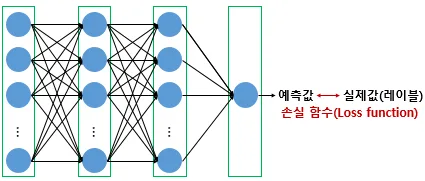

- 실제값과 예측값의 차이를 수치화해주는 함수
- 이 두 값의 차이. 즉, 오차가 클 수록 손실 함수의 값은 크고 오차가 작을 수록 손실 함수의 값은 작아집니다. 회귀에서는 평균 제곱 오차, 분류 문제에서는 크로스 엔트로피를 주로 손실 함수로 사용 
- 손실 함수의 값을 최소화하는 두 개의 매개변수인 가중치 w와
와 편향 b
의 값을 찾는 것이 딥 러닝의 학습 과정이므로 손실 함수의 선정은 매우 중요

### 1) MSE(Mean Squared Error, MSE)

In [13]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

model = Sequential([
    Input(shape=(10,)),
    Dense(64, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import numpy as np

# 샘플 1,000개, 입력 특성 10개
x_train = np.random.rand(1000, 10).astype("float32")

# 샘플마다 정답 1개
y_train = np.random.rand(1000, 1).astype("float32")

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0940 - mse: 0.0940 - val_loss: 0.0915 - val_mse: 0.0915
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0871 - mse: 0.0871 - val_loss: 0.0912 - val_mse: 0.0912
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0859 - mse: 0.0859 - val_loss: 0.0909 - val_mse: 0.0909
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0817 - mse: 0.0817 - val_loss: 0.0891 - val_mse: 0.0891
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0804 - mse: 0.0804 - val_loss: 0.0898 - val_mse: 0.0898
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0791 - mse: 0.0791 - val_loss: 0.0910 - val_mse: 0.0910
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0785 - mse: 0.0785 - val_loss: 0.0900 - val_mse: 0.0900
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0773 - mse: 0.0773 - val_loss: 0.0879 - val_mse: 0.0879
Epoch 9/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0756 - 

In [16]:
print(x_train.shape)  # (1000, 10)
print(y_train.shape)  # (1000, 1)

(1000, 10)
(1000, 1)


In [17]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [18]:
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split

(x, y), (x_final_test, y_final_test) = mnist.load_data()

# 이미지 정규화
x = x.astype("float32") / 255.0

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
%whos

Variable             Type          Data/Info
--------------------------------------------
BinaryCrossentropy   type          <class 'keras.src.losses.<...>sses.BinaryCrossentropy'>
Dense                type          <class 'keras.src.layers.core.dense.Dense'>
Input                function      <function Input at 0x00000254055A9A80>
Sequential           type          <class 'keras.src.models.sequential.Sequential'>
X_new                ndarray       3x10: 30 elems, type `float32`, 120 bytes
X_train              ndarray       1000x10: 10000 elems, type `float32`, 40000 bytes
history              History       <keras.src.callbacks.hist<...>ct at 0x00000254140DB140>
loss                 float         0.0121329789981246
mae                  float         0.08720166236162186
mnist                module        <module 'keras.datasets.m<...>ets\\mnist\\__init__.py'>
model                Sequential    <Sequential name=sequential_5, built=True>
np                   module        <module 'numpy' 

In [20]:
print(x.shape)
print(y.shape)

(60000, 28, 28)
(60000,)


### 2) 이진 크로스 엔트로피(Binary Cross-Entropy)

In [21]:
import numpy as np
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

# 예제 데이터: 입력 특성 10개
X_train = np.random.rand(1000, 10).astype("float32")

# 예제 목표값: 입력값 합계를 예측
y_train = X_train.sum(axis=1).astype("float32")

model = Sequential([
    Input(shape=(10,)),
    Dense(64, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# 모델 학습
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# 새로운 데이터 예측
X_new = np.random.rand(3, 10).astype("float32")
predictions = model.predict(X_new)

print("실제 입력값의 합:")
print(X_new.sum(axis=1))

print("모델 예측값:")
print(predictions.flatten())

model.summary()

loss, mae = model.evaluate(X_train, y_train)
print("MSE:", loss)
print("MAE:", mae)

print(X_train.shape)
print(y_train.shape)

Input(shape=(5,))

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 28.9357 - mae: 5.2885 - val_loss: 22.9685 - val_mae: 4.7008
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 20.0314 - mae: 4.3831 - val_loss: 13.9768 - val_mae: 3.6563
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 10.3906 - mae: 3.1168 - val_loss: 5.1712 - val_mae: 2.2025
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.8142 - mae: 1.5599 - val_loss: 0.6772 - val_mae: 0.7382
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2551 - mae: 0.4018 - val_loss: 0.0938 - val_mae: 0.2443
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0776 - mae: 0.2211 - val_loss: 0.0949 - val_mae: 0.2440
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0695 - mae: 0.2088 - val_loss: 0.0820 - val_mae: 0.2307
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0659 - mae: 0.2036 - val_loss: 0.0791 - val_mae: 0.2252
Epoch 9/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,309 (9.02 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,540 (6.02 KB)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0164 - mae: 0.1010
MSE: 0.016360366716980934
MAE: 0.10102000087499619
(1000, 10)
(1000,)


<KerasTensor shape=(None, 5), dtype=float32, sparse=False, ragged=False, name=keras_tensor_22>

In [24]:
import tensorflow as tf

model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"]
)

In [25]:
from tensorflow.keras.losses import BinaryCrossentropy

model.compile(
    loss=BinaryCrossentropy(),
    optimizer="adam",
    metrics=["accuracy"]
)

In [26]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense

model = Sequential([
    Input(shape=(10,)),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.0000e+00 - loss: 0.0806 - val_accuracy: 0.0000e+00 - val_loss: -2.0257
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0000e+00 - loss: -4.5472 - val_accuracy: 0.0000e+00 - val_loss: -7.0008
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: -10.6692 - val_accuracy: 0.0000e+00 - val_loss: -13.8281
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -18.8332 - val_accuracy: 0.0000e+00 - val_loss: -22.6282
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.0000e+00 - loss: -29.1789 - val_accuracy: 0.0000e+00 - val_loss: -33.5585
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.0000e+00 - loss: -42.0229 - val_accuracy: 0.0000e+00 - val_loss: -47.1334
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: -57.7032 - val_accuracy: 0.0000e+00 - val_loss: -63.3354
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━

### 3) 카테고리칼 크로스 엔트로피(Categorical Cross-Entropy)

In [27]:
model.compile(loss='categorical_crossentropy', optimizer='adam',metrics=['acc'])

In [28]:
model.compile(loss=tf.keras.losses.CategoricalCrossentropy(), optimizer='adam', metrics=['acc'])

In [29]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer='adam', metrics=['acc'])

### 4) 그 외에 다양한 손실 함수들

- 아래의 텐서플로우 공식 문서 링크에서 방금 언급하지 않은 손실 함수 외에도 다양한 손실 함수들을 확인할 수 있습니다.

- https://www.tensorflow.org/api_docs/python/tf/keras/losses

- compile 코드에서 optimizer='adam'이 있습니다. 아담이라는 옵티마이저를 사용했다라는 의미이며, 손실 함수의 선정만큼이나 옵티마이저의 선정 또한 중요합니다.

## 2. 배치 크기(Batch Size)에 따른 경사 하강법

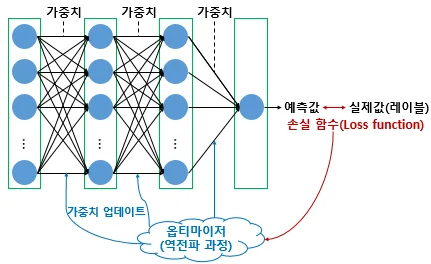

- 손실 함수의 값을 줄여나가면서 학습하는 방법은 어떤 옵티마이저를 사용하느냐에 따라 달라지며, 배치(Batch)라는 개념에 대한 이해가 필요합니다.
- 배치는 가중치 등의 매개 변수의 값을 조정하기 위해 사용하는 데이터의 양을 말합니다.
- 전체 데이터를 가지고 매개 변수의 값을 조정할 수도 있고, 정해준 양의 데이터만 가지고도 매개 변수의 값을 조정할 수 있습니다.